In [1]:
%load_ext autoreload
%autoreload 2 

In [2]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import flax

import solve
import aux_ as aux
import RANK

In [3]:
device = aux.choose_gpu()

cuBLAS < 13.2 (120902 found) has a known issue where many kernels free TMEM buffers multiple times. Executing a cuBLAS kernel concurrently with another kernel (e.g. on another stream) can lead to silent data corruption.


Avaliable devices:
cuda:0

Device = cuda:0 is choosen


In [4]:
model = RANK.RANK_model(device)

E0520 16:21:24.566048 2096751 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 133.76GiB (143621603328 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0520 16:21:24.566550 2096751 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 120.38GiB (129259438080 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0520 16:21:24.567029 2096751 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 108.34GiB (116333494272 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0520 16:21:24.567488 2096751 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 97.51GiB (104700141568 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0520 16:21:24.567947 2096751 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 87.76GiB (9423012

In [ ]:
def compute_sunspot_DSS(model, ZLB):

    par = model.par

    alpha = par["alpha"]
    beta = par["beta"]
    sigma = par["sigma"]
    varphi = par["varphi"]
    epsilon = par["epsilon"]
    kappa = par["kappa"]

    mu = epsilon/(epsilon-1)

    exponent = (1-alpha)/(varphi+alpha+sigma-alpha*sigma)

    first_frac = (beta*(1+ZLB)*(beta*(1+ZLB)-1)*(1-beta)*(1-alpha))/kappa
    second_frac = (1-alpha)/mu

    Y = (first_frac+second_frac)**exponent
    pi = beta*(1+ZLB)-1

    return Y, pi

In [21]:
ZLBs = jnp.linspace(-0.05, 0.00, 100)

In [22]:
Y_ss, pi_ss = compute_sunspot_DSS(model, ZLBs)

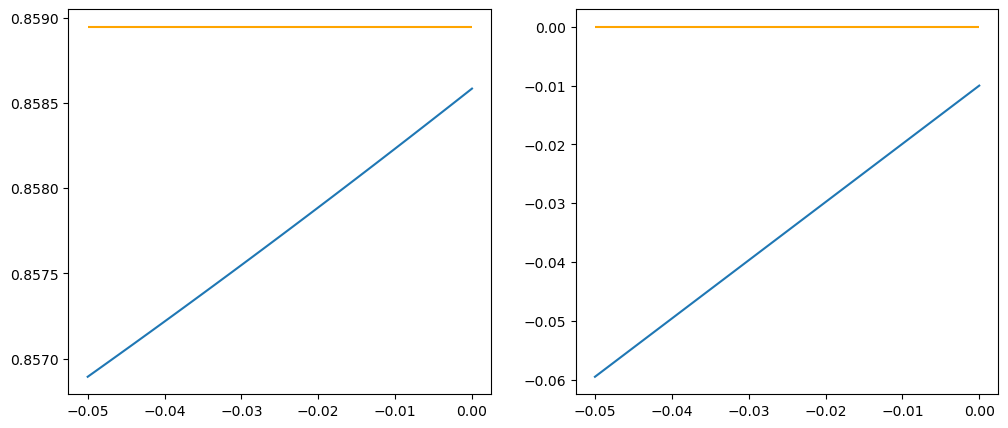

In [32]:
f, ax = plt.subplots(1,2,figsize=(12,5))

ax[0].plot(ZLBs, Y_ss)
ax[1].plot(ZLBs, pi_ss)
ax[0].hlines(model.par["Y_DSS"], -0.05, 0.00, color='orange')
ax[1].hlines(model.par["pi_DSS"], -0.05, 0.00, color='orange')